Lattice setup and energy calculation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
# initialize the codespace with only A-stabilizer 

def lattice_space(L, H):
    lattice = np.zeros((L, H))
    for i in range(L):
        for j in range(H):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
lattice = lattice_space(30, 30)
lattice

array([[0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
        1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.],
       [1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
        0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.],
       [0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
        1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.],
       [1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
        0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.],
       [0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.],
       [1., 1., 0., 1., 1., 0., 1., 1., 0

In [3]:
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = 0
    for i in range(H):
        for j in range(L):
            # Periodic boundary conditions
            right = lattice[(i+1)% H, (j+1) % L]
            down  = lattice[(i+1) % H, j]
            energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice, i, j):
    # Sum over four neighbors with periodic boundaries
    H = lattice.shape[0]
    L = lattice.shape[1]
    s = lattice[i, j]
    ds = (s+1)%2
    left = lattice[i, (j-1)%L] + lattice [(i-1)%H, (j-1)%L]
    right = lattice[(i-1)%H, j] + lattice[i, (j+1)%L]
    bottom = lattice[(i+1)%H, j] + lattice[(i+1)%H, (j+1)%L]
    E  = (left+s)%2 + (right+s)%2 + (bottom+s)%2
    E_new = (left+ds)%2 + (right+ds)%2 + (bottom+ds)%2
    dE = E_new - E
    if dE == 0:
        raise ValueError("No change in energy")
    return dE


lattice = lattice_space(9, 9)
print(energy(lattice))

0.0


Monte carlo error, Monte Carlo local decoder, and kinetic monte carlo local decoder

In [4]:
def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        i = random.randint(0, H - 1)
        j = random.randint(0, L - 1)
        r = random.random()
        if r < error_rate:
            # Flip the qubit
            lattice[i, j] = (lattice[i, j] + 1) % 2
            """
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            """

    return lattice

In [66]:
def local_decoder(lattice, beta, num_steps, error_rate, energy_hist):
    """
    Local decoder that flips qubits based on the energy function.
    """
    for _ in range(num_steps):
        i = random.randint(0, lattice[0] - 1)
        j = random.randint(0, lattice[1] - 1)
        dE = compute_dE(lattice, i, j)
        # if dE < 0:
        #     # Flip the qubit
        #     lattice[i, j] = (lattice[i, j] + 1) % 2
        if random.random() < dE / (1 - np.exp(-beta * dE)) - error_rate:
                lattice[i, j] = (lattice[i, j] + 1) % 2
        energy_hist.append(energy(lattice))
        
    return lattice

In [5]:
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r

def bkl(lattice, steps, energy_hist, error_rate, time_list):
    f = 1e-8
    beta = math.log((3+error_rate)/error_rate)/3
    H = lattice.shape[0]
    L = lattice.shape[1]
    for step in range(steps):
        # for i_ in range(H):
        #     for j_ in range(L):
        #         r = random.random()
        #         if r < error_rate:
        #             # Flip the qubit
        #             lattice[i_, j_] = (lattice[i_, j_] + 1) % 2

        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                dE = compute_dE(lattice, i, j)
                if dE not in classes:
                    classes[dE] = []
                classes[dE].append((i, j))
        # print(classes)
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        rates = {}
        total_rate = 0.0
        for dE in sorted(classes):
            rate = len(classes[dE])* (dE / (np.exp(beta * dE)-1 ) )#- error_rate)
            rates[dE] = rate
            total_rate += rate
        if total_rate == 0:
            print(len(classes), "total_rate is 0")
            continue
        # rate_list = []
        # rate_list.append(total_rate)
        # Choose a class according to the rates (weighted selection)
        r = random.uniform(0, total_rate)
        cumulative = 0.0
        chosen_class = None
        for dE, rate in rates.items():
            cumulative += rate
            if r <= cumulative :
                # print("hi")
                chosen_class = dE
                break
        if total_rate == 0.0:
            raise ValueError("Total rate is zero, cannot choose a class.")
            
        # From the chosen class, select a spin uniformly at random
        i, j = random.choice(classes[chosen_class])
        # Flip the spin
        lattice[i, j] = (lattice[i, j] + 1) % 2
        energy_hist.append(energy(lattice))   
        rho3 = nonzero_random()
        step = -1/total_rate * np.log(rho3)
        # print(rho3, total_rate)
        
        time_list.append(step)
    return lattice

Just exploration to separate bkl algorithm, not related at this point

In [8]:

def bkl_base(lattice, beta, steps, engergy_hist, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    
    # Create a dictionary to group spin flips by their energy change (dE)
    classes = {}
    # For each spin, compute its energy change upon flipping
    for i in range(H):
        for j in range(L):
            dE = compute_dE(lattice, i, j)
            if dE not in classes:
                classes[dE] = []
            classes[dE].append((i, j))
    # print(classes)
    # Calculate transition rates for each class:
    # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
    # for dE > 0, it is dE*(1-exp(-beta * dE))
    rates = {}
    total_rate = 0.0
    for dE in sorted(classes):
        rate = len(classes[dE])* (dE / (1 - np.exp(-beta * dE)) - error_rate)
        rates[dE] = rate
        total_rate += rate
    
    # Choose a class according to the rates (weighted selection)
    r = random.uniform(0, total_rate)
    cumulative = 0.0
    chosen_class = None
    for dE, rate in rates.items():
        cumulative += rate
        if r <= cumulative :
            print("hi")
            chosen_class = dE
            # break
    
    # From the chosen class, select a spin uniformly at random
    i, j = random.choice(classes[chosen_class])
    # Flip the spin
    lattice[i, j] = (lattice[i, j] + 1) % 2
    new_label =compute_dE(lattice, i, j)
    classes[new_label].append((i, j))
    # Remove the flipped spin from its old class   
    classes[chosen_class].remove((i, j))    

    return lattice, classes

def bkl_evolve(lattice, classes, beta, steps, engergy_hist, error_rate):
    rates = {}
    total_rate = 0.0
    for dE in sorted(classes):
        rate = len(classes[dE])* (dE / (1 - np.exp(-beta * dE)) - error_rate)
        rates[dE] = rate
        total_rate += rate
    
    # Choose a class according to the rates (weighted selection)
    r = random.uniform(0, total_rate)
    cumulative = 0.0
    chosen_class = None
    for dE, rate in rates.items():
        cumulative += rate
        if r <= cumulative :
            print("hi")
            chosen_class = dE
            # break
    
    # From the chosen class, select a spin uniformly at random
    i, j = random.choice(classes[chosen_class])
    # Flip the spin
    lattice[i, j] = (lattice[i, j] + 1) % 2
    new_label =compute_dE(lattice, i, j)
    classes[new_label].append((i, j))
    # Remove the flipped spin from its old class   
    classes[chosen_class].remove((i, j))    

    return lattice, classes

Engery evolution in Monte carlo errors and in bkl local decoder with respect to bkl time steps

0.0


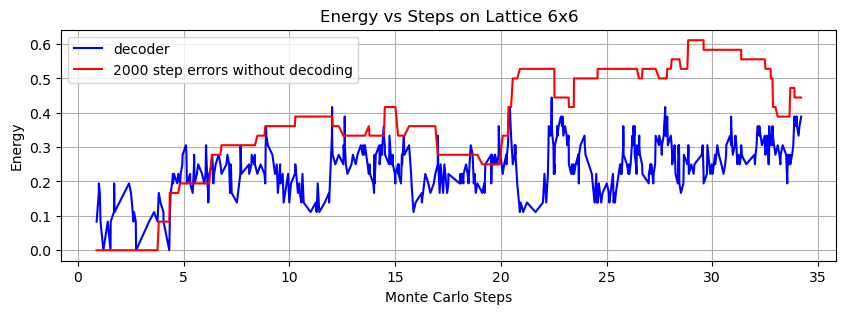

In [68]:
error_rate =0.1
classes = {}
energy_hist1 = []
time_list_0 = []
H = 6
L = 6
E = H * L
Lattice = lattice_space(H, L)
lattice = Lattice.copy()
# lattice = monte_carlo_error(lattice, 1000, error_rate)
print(energy(lattice))
random.seed(0)
bkl(lattice, 500, energy_hist1, error_rate, time_list_0)

bar_list = [] 
lattice1 = Lattice.copy()
for i in range(len(time_list_0)):
    lattice1 = monte_carlo_error(lattice1, int(time_list_0[i]+1), error_rate)
    bar_list.append(energy(lattice1))
energy_hist1 = np.array(energy_hist1) / E
bar_list = np.array(bar_list) / E
time_arr_0       = np.array(time_list_0)
time_list_full_0 = np.cumsum(time_arr_0)
# plot the decoding process in energy changes
x = np.arange(len(energy_hist1))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(time_list_full_0, energy_hist1, color ='blue', label='decoder')
plt.plot(time_list_full_0, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




0.0


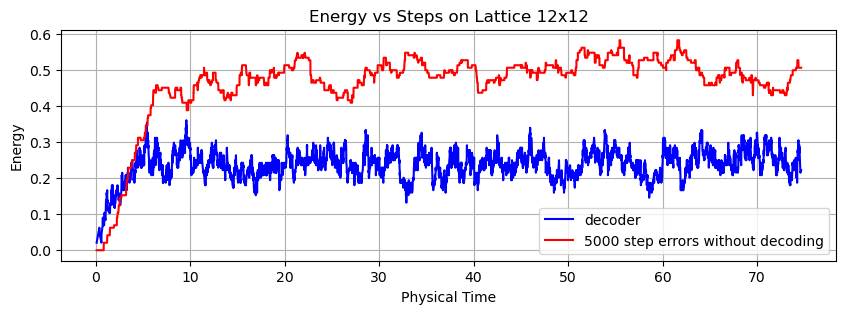

In [6]:
error_rate =0.1
classes = {}
energy_hist_12 = []
time_list_12 = []
H = 12
L = 12
E = 12 * 12 
Lattice = lattice_space(H, L)
lattice = Lattice.copy()
beta = math.log((3+error_rate)/error_rate)/3
# lattice = monte_carlo_error(lattice, 1000, error_rate)
print(energy(lattice))
bkl(lattice, 5000, energy_hist_12, error_rate, time_list_12)


bar_list = [] 
lattice1 = Lattice.copy()
for i in range(5000):
    lattice1 = monte_carlo_error(lattice1, int(time_list_12[i]+1), error_rate)
    bar_list.append(energy(lattice1))
# for i in range(len(time_list)):
#     lattice1 = monte_carlo_error(lattice1, int(time_list[i]+1), error_rate)
#     bar_list.append(energy(lattice1))
    
    
energy_hist4 = np.array(energy_hist_12) / E
bar_list = np.array(bar_list) / E
# plot the decoding process in energy changes
time_arr       = np.array(time_list_12)
time_list_full = np.cumsum(time_arr)
x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(time_list_full, np.array(energy_hist_12) / E, color ='blue', label='decoder')
plt.plot(time_list_full, bar_list, color ='red',  label='5000 step errors without decoding')
plt.xlabel('Physical Time')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




In [113]:
print(time_list)

[np.float64(0.16421358348715723), np.float64(0.0870167304604693), np.float64(0.0009952250536439046), np.float64(0.0223000840086941), np.float64(0.01010399607949453), np.float64(0.04895403619955328), np.float64(0.02495709986531406), np.float64(0.03585945580853235), np.float64(0.07513801372391841), np.float64(0.031212340540887878), np.float64(0.008107772807472229), np.float64(0.025622483126023558), np.float64(0.010587210567478793), np.float64(0.010287156628362255), np.float64(0.009604765522506064), np.float64(0.03795777246776787), np.float64(0.008695032791740154), np.float64(0.05405425890763602), np.float64(0.019709828866108264), np.float64(0.002771694810375179), np.float64(0.0017700065576470555), np.float64(0.07707509388078751), np.float64(0.007531852465196061), np.float64(0.005096305340768008), np.float64(0.002613867419571452), np.float64(0.0020942207623462347), np.float64(0.025770223738225476), np.float64(0.0031495131178534024), np.float64(0.005274975641746602), np.float64(0.004285005

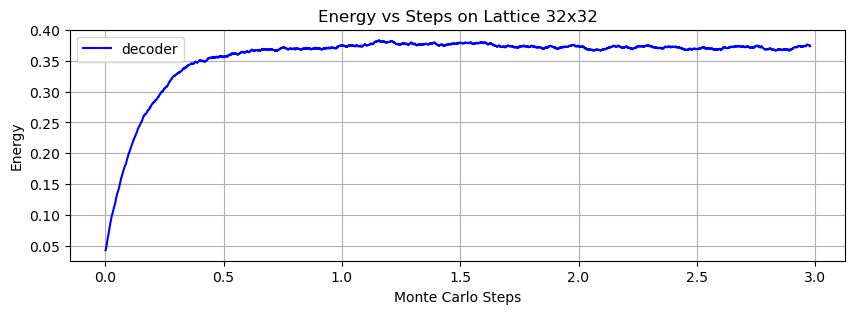

In [28]:
error_rate =0.8
classes = {}
energy_hist1 = []
time_list = []
H = 32
L = 32
E = H * L

num_runs  = 30
num_steps = 5000

# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs = np.zeros((num_runs, num_steps))
decoder_times = np.zeros((num_runs, num_steps))  # if bkl populates it; otherwise you can drop it
for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs[run_idx, :] = energy_list
    decoder_times[run_idx, :] = time_list  # if bkl populates it; otherwise you can drop it
# compute average (and normalize)
mean_decoder = decoder_trajs.mean(axis=0) / E
std_decoder = decoder_trajs.std(axis=0) / E
mean_times = decoder_times.mean(axis=0)  # if bkl populates it; otherwise you can drop it   
mean_times_cum = np.cumsum(mean_times)


# bar_list = [] 
# lattice1 = Lattice.copy()
# for i in range(10000):
#     lattice1 = monte_carlo_error(lattice1, 1, error_rate)
#     bar_list.append(energy(lattice1))
# for i in range(len(time_list)):
#     lattice1 = monte_carlo_error(lattice1, int(time_list[i]+1), error_rate)
#     bar_list.append(energy(lattice1))
# energy_hist = np.array(energy_hist) / E
# bar_list = np.array(bar_list) / E
# plot the decoding process in energy changes
x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum, mean_decoder, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




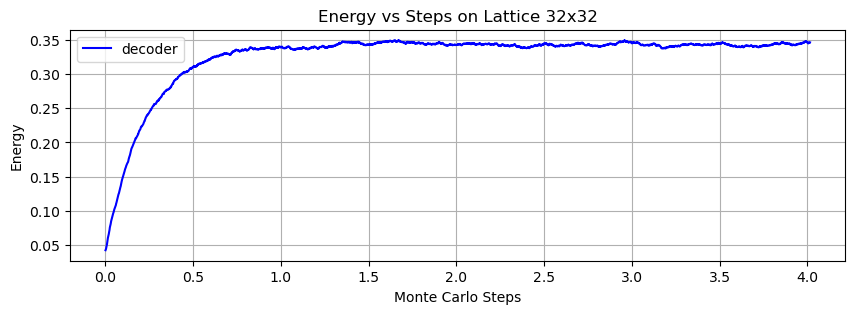

In [29]:
error_rate =0.5
num_runs  = 30
num_steps = 5000

# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs1 = np.zeros((num_runs, num_steps))
decoder_times1 = np.zeros((num_runs, num_steps))
for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs1[run_idx, :] = energy_list
    decoder_times1[run_idx, :] = time_list
# compute average (and normalize)
mean_decoder1 = decoder_trajs1.mean(axis=0) / E
std_decoder1 = decoder_trajs1.std(axis=0) / E
mean_times1 = decoder_times1.mean(axis=0)
mean_times_cum1 = np.cumsum(mean_times1)


x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum1, mean_decoder1, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()


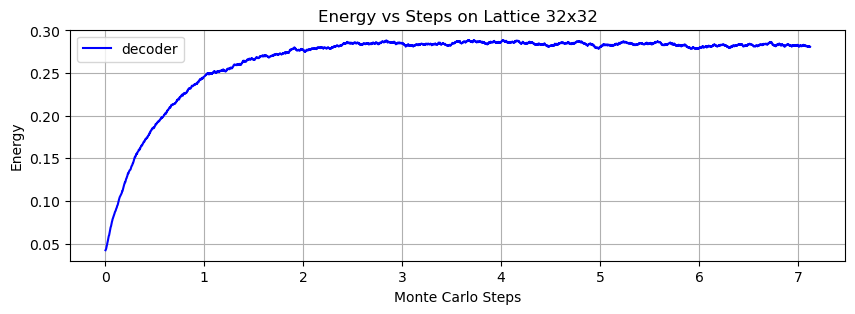

In [30]:
error_rate =0.2
num_runs  = 30
num_steps = 5000

# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs2 = np.zeros((num_runs, num_steps))
decoder_times2 = np.zeros((num_runs, num_steps))
for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs2[run_idx, :] = energy_list
    decoder_times2[run_idx, :] = time_list
# compute average (and normalize)
mean_decoder2 = decoder_trajs2.mean(axis=0) / E
std_decoder2 = decoder_trajs2.std(axis=0) / E
mean_times2 = decoder_times2.mean(axis=0) 
mean_times_cum2 = np.cumsum(mean_times2)


x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum2, mean_decoder2, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()


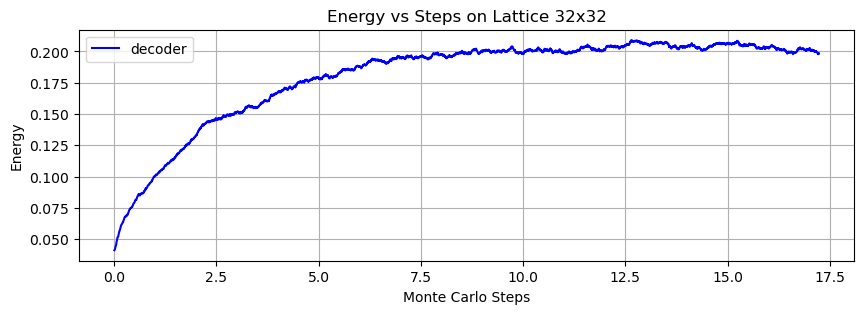

In [31]:
error_rate =0.05
num_runs  = 30
num_steps = 5000

# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs3 = np.zeros((num_runs, num_steps))
decoder_times3 = np.zeros((num_runs, num_steps))
for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs3[run_idx, :] = energy_list
    decoder_times3[run_idx, :] = time_list
# compute average (and normalize)
mean_decoder3 = decoder_trajs3.mean(axis=0) / E
std_decoder3 = decoder_trajs3.std(axis=0) / E
mean_times3 = decoder_times3.mean(axis=0)
mean_times_cum3 = np.cumsum(mean_times3)

x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum3, mean_decoder3, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()


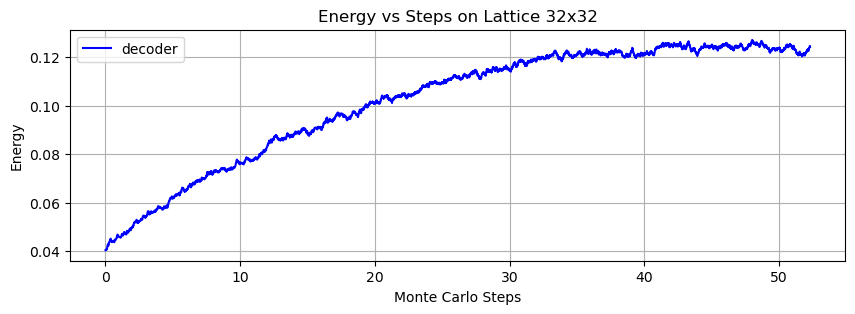

In [32]:
error_rate =0.01
num_runs  = 30
num_steps = 5000

# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs4 = np.zeros((num_runs, num_steps))
decoder_times4 = np.zeros((num_runs, num_steps))
for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs4[run_idx, :] = energy_list
    decoder_times4[run_idx, :] = time_list
# compute average (and normalize)
mean_decoder4 = decoder_trajs4.mean(axis=0) / E
std_decoder4 = decoder_trajs4.std(axis=0) / E
mean_time4 = decoder_times4.mean(axis=0)
mean_times_cum4 = np.cumsum(mean_time4)

x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum4, mean_decoder4, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()


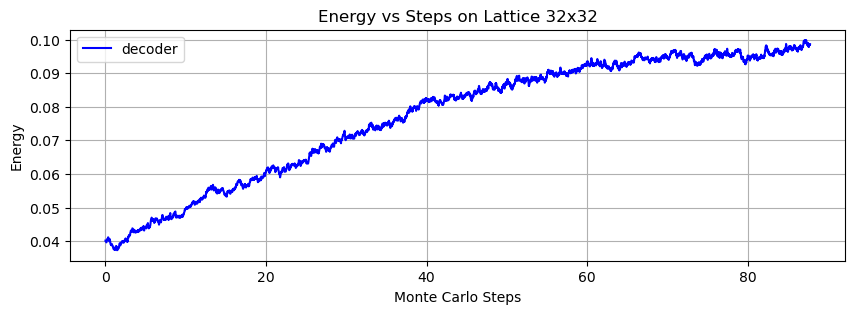

In [33]:
error_rate =0.005
num_runs  = 30
num_steps = 5000
H = 32
L = 32
E = H * L


# ------------------------------------------
# 1) Collect all decoder (bkl) trajectories
# ------------------------------------------
decoder_trajs5 = np.zeros((num_runs, num_steps))
decoder_times5 = np.zeros((num_runs, num_steps))

for run_idx, seed in enumerate(range(num_runs)):
    random.seed(seed)
    lattice = lattice_space(H, L).copy()
    

    energy_list = []
    time_list_i   = []            # if bkl populates it; otherwise you can drop it
    bkl(lattice, num_steps, energy_list, error_rate, time_list_i)

    if len(energy_list) != num_steps:
        raise ValueError(f"Run {run_idx}: expected {num_steps} energies, got {len(energy_list)}")

    decoder_trajs5[run_idx, :] = energy_list
    decoder_times5[run_idx, :] = time_list_i

# compute average (and normalize)
mean_decoder5 = decoder_trajs5.mean(axis=0) / E
std_decoder5 = decoder_trajs5.std(axis=0) / E
mean_times5 = decoder_times5.mean(axis=0)
mean_times_cum5 = np.cumsum(mean_times5)



x = np.arange(5000)
# x = np.arange(len(energy_hist))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum5, mean_decoder5, color ='blue', label='decoder')
# plt.plot(x, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()


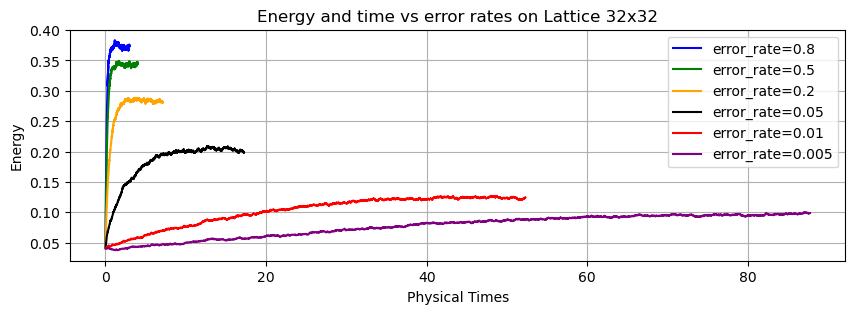

In [34]:
x = np.arange(5000)

plt.figure(figsize=(10, 3))
plt.plot(mean_times_cum, mean_decoder, color ='blue', label='error_rate=0.8')
plt.plot(mean_times_cum1, mean_decoder1, color ='green', label='error_rate=0.5')
plt.plot(mean_times_cum2, mean_decoder2, color ='orange', label='error_rate=0.2')
plt.plot(mean_times_cum3, mean_decoder3, color ='black', label='error_rate=0.05')
plt.plot(mean_times_cum4, mean_decoder4, color ='red', label='error_rate=0.01')
plt.plot(mean_times_cum5, mean_decoder5, color ='purple', label='error_rate=0.005')

plt.xlabel('Physical Times')
plt.ylabel('Energy')
plt.title(f'Energy and time vs error rates on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()

In [35]:
import bisect
error_rates = [0.8, 0.5, 0.2, 0.05, 0.01, 0.005]

decoder_trajs = [mean_decoder[1000:].mean(), mean_decoder1[1500:].mean(), mean_decoder2[2000:].mean(), mean_decoder3[2500:].mean(), mean_decoder4[3000:].mean(), mean_decoder5[3500:].mean()]
t1 = bisect.bisect_right(mean_decoder, mean_decoder[1000:].mean())
t2 = bisect.bisect_right(mean_decoder1,mean_decoder1[1500:].mean())
t3 = bisect.bisect_right(mean_decoder2,mean_decoder1[2000:].mean())
t4 = bisect.bisect_right(mean_decoder3,mean_decoder1[2500:].mean())
t5 = bisect.bisect_right(mean_decoder4,mean_decoder1[3000:].mean())
t6 = bisect.bisect_right(mean_decoder5,mean_decoder1[3500:].mean())
times = [t1, t2, t3, t4, t5, t6]
sat_times = [mean_times_cum[t1-1], mean_times_cum1[t2-1], mean_times_cum2[t3-1], mean_times_cum3[t4-1], mean_times_cum4[t5-1], mean_times_cum5[t6-1]]


In [36]:
print(times)
print(decoder_trajs)


[1573, 1545, 5000, 5000, 5000, 5000]
[np.float64(0.3728666015625), np.float64(0.34328141741071433), np.float64(0.2838075954861111), np.float64(0.20294302083333332), np.float64(0.12311598307291666), np.float64(0.09551532118055556)]


In [37]:
print(std_decoder5.mean())
print(std_decoder4.mean())
print(std_decoder3.mean())
print(std_decoder2.mean())
print(std_decoder1.mean())


0.010794352360013955
0.010063393632737927
0.012031962797763997
0.01367081829069093
0.014117093868612983


$ E = \frac{J}{1 + e^{\beta J}} $ \\


[0.37299686184, 0.343296815906, 0.284103653417, 0.20257278854, 0.129840462246, 0.105943316336]

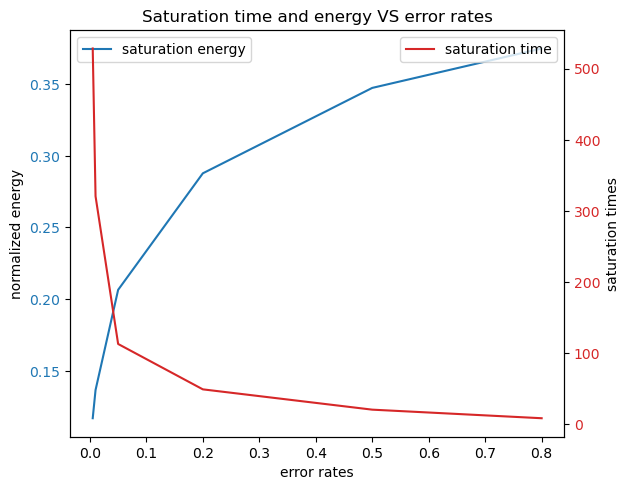

In [172]:
import matplotlib.pyplot as plt



fig, ax1 = plt.subplots()

# Plot the first series on ax1
ax1.plot(error_rates, decoder_trajs, color='tab:blue', label='saturation energy')
ax1.set_xlabel('error rates')
ax1.set_ylabel('normalized energy')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.legend()
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
ax2.plot(error_rates, sat_times, color='tab:red', label='saturation time')
ax2.set_ylabel('saturation times')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.legend()
plt.title("Saturation time and energy VS error rates")
plt.show()


0.0


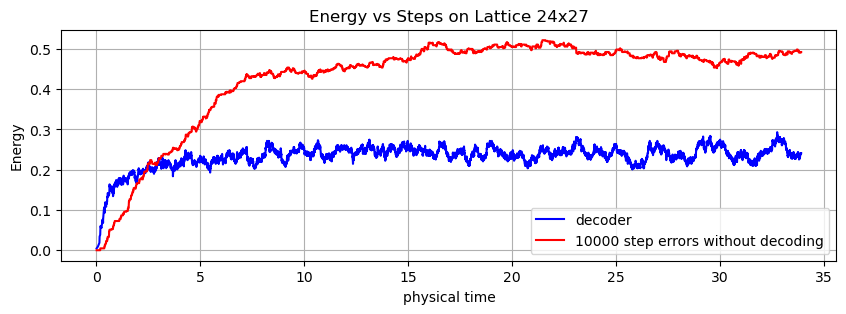

In [176]:
error_rate =0.1
classes = {}
energy_hist_1 = []
time_list_1 = []
H = 24
L = 27
E = H * L
Lattice = lattice_space(H, L)
lattice = Lattice.copy()
beta = math.log((3+error_rate)/error_rate)/3
# lattice = monte_carlo_error(lattice, 1000, error_rate)
print(energy(lattice))
bkl(lattice, 10000, energy_hist_1, error_rate, time_list_1)

bar_list = [] 
lattice1 = Lattice.copy()
for i in range(len(time_list_1)):
    lattice1 = monte_carlo_error(lattice1, int(time_list_1[i]+1), error_rate)
    bar_list.append(energy(lattice1))
    # print(energy(lattice1))
energy_hist_1 = np.array(energy_hist_1) / E
bar_list = np.array(bar_list) / E
time_arr_1       = np.array(time_list_1)

time_list_full_1 = np.cumsum(time_arr_1)
# plot the decoding process in energy changes
x = np.arange(len(energy_hist_1))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(time_list_full_1, energy_hist_1, color ='blue', label='decoder')
plt.plot(time_list_full_1, bar_list, color ='red',  label='10000 step errors without decoding')
plt.xlabel('physical time')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




0.0


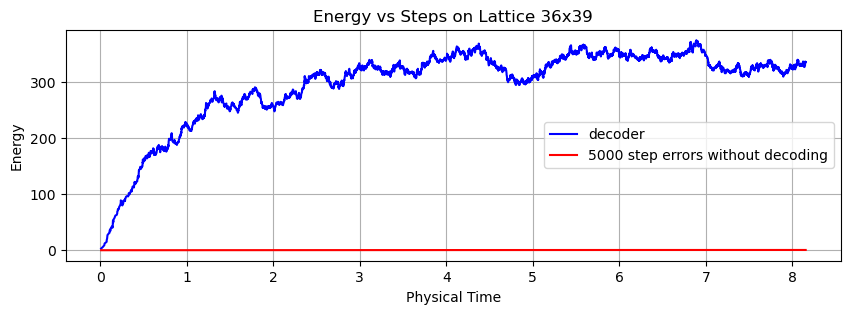

In [179]:
error_rate =0.1
classes = {}
energy_hist_2 = []
time_list_2 = []
H = 36
L = 39
E = H * L
Lattice = lattice_space(H, L)
lattice = Lattice.copy()

beta = math.log((3+error_rate)/error_rate)/3
# lattice = monte_carlo_error(lattice, 1000, error_rate)
print(energy(lattice))
bkl(lattice, 5000, energy_hist_2, error_rate, time_list_2)

bar_list = [] 
lattice1 = Lattice.copy()
for i in range(len(time_list_2)):
    lattice1 = monte_carlo_error(lattice1, int(time_list_2[i]+1), error_rate)
    bar_list.append(energy(lattice1))
    # print(energy(lattice1))
energy_hist_1 = np.array(energy_hist_2) / E
bar_list = np.array(bar_list) / E
time_arr_2     = np.array(time_list_2)
time_list_full_2 = np.cumsum(time_arr_2)
# plot the decoding process in energy changes
x = np.arange(len(energy_hist_1))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(time_list_full_2, energy_hist_2, color ='blue', label='decoder')
plt.plot(time_list_full_2, bar_list, color ='red',  label='5000 step errors without decoding')
plt.xlabel('Physical Time')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




0.0


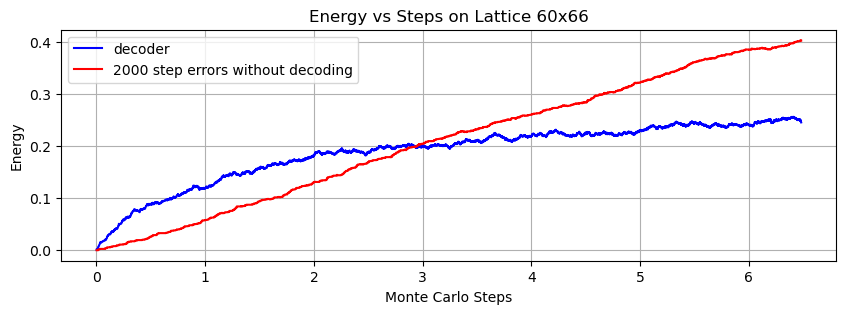

In [180]:
error_rate =0.1
classes = {}
energy_hist_3 = []
time_list_3 = []
H = 60
L = 66
E = H * L
Lattice = lattice_space(H, L)
lattice = Lattice.copy()
beta = math.log((3+error_rate)/error_rate)/3
# lattice = monte_carlo_error(lattice, 1000, error_rate)
print(energy(lattice))
bkl(lattice, 10000, energy_hist_3, error_rate, time_list_3)

bar_list = [] 
lattice1 = Lattice.copy()
for i in range(len(time_list_3)):
    lattice1 = monte_carlo_error(lattice1, int(time_list_3[i]+1), error_rate)
    bar_list.append(energy(lattice1))
    # print(energy(lattice1))
energy_hist_3 = np.array(energy_hist_3) / E
bar_list = np.array(bar_list) / E
time_arr_3     = np.array(time_list_3)
time_list_full_3 = np.cumsum(time_arr_3)
# plot the decoding process in energy changes
x = np.arange(len(energy_hist_3))
# bar = np.full(shape=len(energy_hist), fill_value=bar)
plt.figure(figsize=(10, 3))
plt.plot(time_list_full_3, energy_hist_3, color ='blue', label='decoder')
plt.plot(time_list_full_3, bar_list, color ='red',  label='2000 step errors without decoding')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Energy')
plt.title(f'Energy vs Steps on Lattice {H}x{L}')
plt.legend()
plt.grid()
plt.show()




In [82]:
energy_hist_[3000:].mean()

np.float64(0.23573347763347763)

In [ ]:
import itertools

def exact_thermal_energy():
    Z = 0.0
    E_sum = 0.0
    for bits in itertools.product([0,1], repeat=N):
        s = np.array(bits).reshape(shape)  # shape = (L, L, 2)
        Hs = energy(s)
        w  = np.exp(-β * Hs)
        Z += w
        E_sum += Hs * w
    return E_sum / Z


In [186]:
print(es)

[np.float64(0.24315625), np.float64(0.00036502299426682144), np.float64(0.23653490028490032), np.float64(5.387111859334082e-05)]


[144, 648, 1296, 3960] 0.24315625 0.00036502299426682144 0.23653490028490032


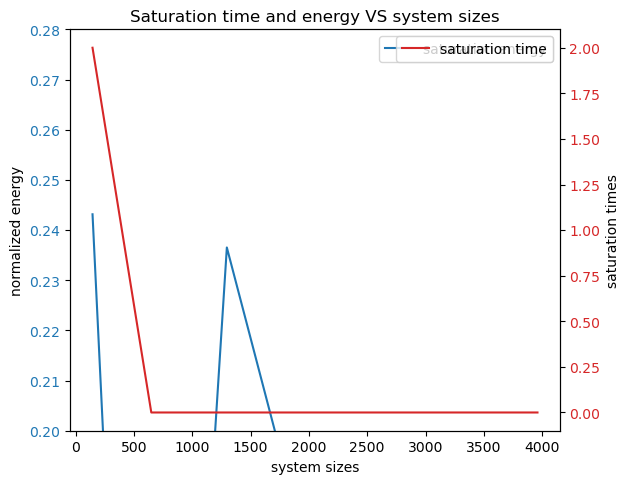

In [184]:
e1 = np.array(energy_hist_12[1000:]).mean()/144
e2 = np.array(energy_hist_1[1000:]).mean()/(24*27)
# energy_hist_4 = np.array(energy_hist_3) / (6*6)
e3 = np.array(energy_hist_2[1000:]).mean()/(36*39)
e4 = np.array(energy_hist_3[1000:]).mean()/(60*66)
sizes = [12*12, 24*27, 36*36, 60*66]
es = [e1, e2, e3, e4]
print(sizes, e1, e2, e3)
t1 = bisect.bisect_right(energy_hist_12, e1)
t2 = bisect.bisect_right(energy_hist_1, e2)
t3 = bisect.bisect_right(energy_hist_2, e3)
t4 = bisect.bisect_right(energy_hist_3, e4)
ts = [t1, t2, t3, t4]
fig, ax1 = plt.subplots()

# Plot the first series on ax1
ax1.plot(sizes, es, color='tab:blue', label='saturation energy')
ax1.set_xlabel('system sizes')
ax1.set_ylabel('normalized energy')
ax1.set_ylim(0.2,0.28)
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.legend()
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
ax2.plot(sizes, ts, color='tab:red', label='saturation time')
ax2.set_ylabel('saturation times')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.legend()
plt.title("Saturation time and energy VS system sizes")
plt.show()


import math
import numpy as np
# constants
L = 1000
H = 1000
error_rate = 0.00001
beta = math.log((6+error_rate)/error_rate)/6       # Inverse temperature
step_list = [1000, 3000, 5000, 10000, 30000, 50000, 70000, 100000, 150000, 3000000, 350000, 4000000, 5000000]    # Number of Monte Carlo steps
energy_hist = np.empty((len(step_list), 2))

# Test the local decoder with different step sizes
for k in range(len(step_list)):
    
    # Initialize the lattice
    lattice = lattice_space(L, H)
    lattice = monte_carlo_error(lattice, 1000, error_rate)
    print("Initial energy:", energy(lattice))
    energy_hist[k][0] = energy(lattice)
    final_lattice = local_decoder(lattice, beta, step_list[k], error_rate)
    print("Final energy:", energy(final_lattice))
    energy_hist[k][1] = energy(final_lattice)

i = energy_hist[9][1]
energy_hist[9][1] = energy_hist[10][1]
energy_hist[10][1] = i  

import matplotlib.pyplot as plt
plt.plot(step_list, energy_hist[:, 0], label='Initial Energy')
plt.plot(step_list, energy_hist[:, 1], label='Final Energy')
plt.xlabel('Number of Steps')
plt.ylabel('Energy')
plt.title('Energy vs Number of Steps')
plt.legend()
plt.show()


i = energy_hist[9][1]
energy_hist[9][1] = energy_hist[10][1]
energy_hist[10][1] = i

import matplotlib.pyplot as plt
plt.plot(step_list, energy_hist[:, 0], label='Initial Energy')
plt.plot(step_list, energy_hist[:, 1], label='Final Energy')
plt.xlabel('Number of Steps')
plt.ylabel('Energy')
plt.title('Energy vs Number of Steps')
plt.legend()
plt.show()

The actual optimal decoder

In [3]:
# optimal decoder

def syndrome_detector(lattice):
    """
    Detects errors in syndrom measuring A-stabilizer
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = []
    #errors = np.zeros((H,L))
    for i in range(H):
        for j in range(L):
            if (lattice[i, j]+lattice[i, (j+1)%L]+lattice[(i+1)%H, (j+1)%L]) % 2 != 0:  # error by A-stablizer
                #errors[i][j]= 1
                errors.append((i,j))   
    return errors

def error_qubit_detector(lattice):
    """
    Detects errors in the lattice and returns a list of qubits to be flipped.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = syndrome_detector(lattice)
    error_qubits = np.zeros((H,L),dtype=int)
    for i in range(H):
        for j in range(L):
            if not (errors[i][j] or errors[(i-1)%H][j] or errors[(i-1)%H][(j-1)%L]):  
                error_qubits[i][j]= 1   # Assuming 1 indicates an error
    return error_qubits

def sweeper(lattice):
    """
    Sweeps through the lattice and move the defects. to the first row.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    errors = np.zeros((H,L))
    
    for i in range(H-1):      # to H or H-1?/
        for j in range(L):
            if (lattice[(H-i-1)%H, j]+lattice[(H-i)%H, j]+lattice[(H-i)%H, (j+1)%L]) % 2 == 1:  # error by A-stablizer
                errors[(H-i-1)%H][j]= 1
                lattice[(H-i-1)% H][j] = (lattice[(H-i-1) % H][j] + 1) % 2 
    return lattice, errors

def update_rule(lattice):
    """
    Update rule 102, input row_i+1, returns row_i
    """
    # H = lattice.shape[0]
    L = lattice.shape[1]
    f = np.zeros((L,L),dtype=int)
    for j in range(L):
        for i in range(L):
            if j % 3 ==0 and i % 3 == 0:
                f[j][i] = 1
            if j % 3 == 0 and i % 3 == 1:
                f[j][i] = 1
            if j % 3 == 1 and i % 3 == 1:
                f[j][i] = 1
            if j % 3 == 1 and i % 3 == 2:
                f[j][i] = 1
            if j % 3 == 2 and i % 3 == 0:
                f[j][i] = 1
            if j % 3 == 2 and i % 3 == 2:
                f[j][i] = 1
    
    return f

def cyclic_shift(L):
    """
    Return the L×L matrix P which, when you do P @ v,
    cyclically shifts the entries of v up by one:

       (Pv)[i] = v[(i+1) % L].
    """
    P = np.zeros((L, L), dtype=int)
    for i in range(L):
        P[i, (i+1) % L] = 1
    return P

def invert_mod2(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of a square binary matrix A over GF(2).
    
    Parameters
    ----------
    A : (n,n) array_like of {0,1}
        The matrix to invert; must be square and of full rank mod 2.
    
    Returns
    -------
    A_inv : (n,n) ndarray of {0,1}
        The inverse of A in Z_2, so that A_inv @ A ≡ I mod 2.
    
    Raises
    ------
    ValueError
        If A is not square or not invertible over Z_2.
    """
    A = np.array(A, dtype=np.uint8) & 1
    n, m = A.shape
    if n != m:
        raise ValueError(f"Matrix must be square, got shape {A.shape}")
    
    # Build the augmented matrix [A | I]
    aug = np.concatenate([A, np.eye(n, dtype=np.uint8)], axis=1)  # shape (n, 2n)
    
    # Gauss–Jordan elimination
    row = 0
    for col in range(n):
        # 1) Find a pivot in or below current row
        pivot = None
        for r in range(row, n):
            if aug[r, col]:
                pivot = r
                break
        if pivot is None:
            # no pivot => singular
            raise ValueError("Matrix is singular in GF(2), cannot invert")
        
        # 2) Swap pivot row into place if needed
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]
        
        # 3) Eliminate all other 1’s in this column
        for r in range(n):
            if r != row and aug[r, col]:
                # row r ← row r XOR row 'row'
                aug[r, :] ^= aug[row, :]
        
        row += 1
    
    # At this point the left n×n block is I, so the right block is A^{-1}
    A_inv = aug[:, n:]  # shape (n, n)
    A_inv = A_inv.astype(np.uint8) & 1  # ensure binary
    return A_inv

def optimal_decoder(lattice):
    """
    Optimal decoder using sweeper. # treat S as column vector
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    S = np.zeros((1,L), dtype=int)
    for i in range(L):
        if (lattice[0][i] + lattice[1][i]+lattice[1][(i+1)%L]) % 2 == 1:
            S[0][i] = 1
        # S[i] = lattice[0, i]
    S = np.transpose(S)  
    print("S", S)
    # S = np.transpose(lattice[0])
    f = update_rule(lattice)
    f = np.linalg.matrix_power(f, H-1) % 2
    # print(f)
    P = cyclic_shift(L)
    # f1 = f.copy() 
    # for i in range(L):
    #     f1[:,(i+1) % L] = f[:,i] #######################. is it i+1 or i-1?

    A = (np.eye(L) + f + P @ f) % 2
    print(A)
    A_inv = invert_mod2(A)
    E = (A_inv @ S ) % 2
    # E = np.transpose(E)
    # diff = E - S
    """
    try:
        A_inv = np.linalg.inv(A)
        
        # Step 4: Validate by checking that A * A_inv is approximately the identity matrix.
        identity = np.dot(A, A_inv)
        
        if np.allclose(identity, np.eye(A.shape[0])):
            print("\nThe inversion is verified: A * A_inv is approximately the identity matrix.")
        else:
            print("\nWarning: A * A_inv is not the identity matrix.")
        
    except np.linalg.LinAlgError:
        print("The matrix is singular and cannot be inverted.")

    """
    return E
    # return e_int, S, E, diff

def C2_constructor(E, lattice):
    """
    Construct the C2 code from the error syndrome in line 0. Again E is the first row written as column vector.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    C2 = np.zeros((L, H))
    E = E.squeeze()  # Ensure E is a 1D array
    f = update_rule(lattice)
    for i in range(H):
        C2[:,(H-i)%H] = (np.linalg.matrix_power(f, i) & 1 ) @ E
    C2 = np.transpose(C2)
    return C2

def logical_operators(lattice):
    H = lattice.shape[0]
    L = lattice.shape[1]
    lattice = np.array(lattice_space(H, L))
    f = update_rule(lattice)
    lattice1 = np.transpose(f @ np.transpose(lattice)  % 2)
    lattice2 = (lattice + lattice1) % 2
    lattice3 = np.zeros((H, L))
    logicals = [lattice, lattice1, lattice2, lattice3]      # 1. in x direction 2. in y direction 3. in both directions 4.vaccum
    return logicals

def logical_checks(lattice, x):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    Lattice = lattice_space(H, L)
    R = logical_operators(Lattice)
    syndrome, C1 = sweeper(lattice)
    print("syndrome", syndrome)
    E = optimal_decoder(syndrome)
    # S = np.transpose(syndrome[0])
    # f = update_rule(Lattice)
    # f = np.linalg.matrix_power(f, H-1) % 2
    # P = cyclic_shift(L)
    # A = np.eye(L) + f + f @ P
    # A_inv = invert_mod2(A)
    # E = (A_inv @ S ) % 2
    if C1.all() == None:
        return True
    C2 = C2_constructor(E, Lattice)
    weights = [( (R_i + C1 + C2) % 2 ).sum() for R_i in R]
    min_weight = min(weights)
    min_index = weights.index(min_weight)
    print(weights)
  
    if min_index != x:
        return False #min_index
    else:
        return True


NameError: name 'np' is not defined

In [1]:
def solve_mod2(A, y):
    """
    Solve y = A x over GF(2).  Returns (x_particular, nullspace_basis).
    If no solution exists, raises ValueError.
    """
    A = np.array(A, dtype=np.uint8) & 1
    y = np.array(y, dtype=np.uint8).flatten() & 1
    r, c = A.shape

    # Build augmented matrix [A | y]
    aug = np.concatenate([A.copy(), y.reshape(-1,1)], axis=1)

    pivot_cols = []
    row = 0

    # Forward elimination in GF(2)
    for col in range(c):
        # Find a row i≥row with aug[i,col] == 1
        pivot = None
        for i in range(row, r):
            if aug[i, col] == 1:
                pivot = i
                break
        if pivot is None:
            continue  # free column

        # Swap that pivot row into position `row`
        if pivot != row:
            aug[[row, pivot], :] = aug[[pivot, row], :]

        # Eliminate all other 1’s in this column by XOR
        for i in range(r):
            if i != row and aug[i, col] == 1:
                aug[i, :] ^= aug[row, :]

        pivot_cols.append(col)
        row += 1
        if row == r:
            break

    # Check for inconsistency: any row [0 … 0 | 1] means no solution
    for i in range(row, r):
        if np.all(aug[i, :c] == 0) and aug[i, c] == 1:
            raise ValueError("No solutions exist for A x = y (mod 2).")

    # Identify free variables
    pivot_set = set(pivot_cols)
    free_cols = [col for col in range(c) if col not in pivot_set]

    # Build one particular solution: set all free x[j]=0
    x_part = np.zeros(c, dtype=np.uint8)
    for i, pcol in enumerate(pivot_cols):
        x_part[pcol] = aug[i, c]

    # Build nullspace basis (not needed here, but returned for completeness)
    nullspace_basis = []
    for f in free_cols:
        x_hom = np.zeros(c, dtype=np.uint8)
        x_hom[f] = 1
        for i, pcol in enumerate(pivot_cols):
            if aug[i, f] == 1:
                x_hom[pcol] = 1
        nullspace_basis.append(x_hom)

    return x_part, nullspace_basis

In [30]:
def optimal_decoder_test(lattice):
    """
    Optimal decoder using sweeper.
    """
    H = lattice.shape[0]
    L = lattice.shape[1]
    # lattice1, _ = sweeper(lattice)
    S = lattice[0]
    f = update_rule(lattice)
    f = np.linalg.matrix_power(f, H) % 2
    f1 = f 
    for i in range(L):
        f1[:,(i-1) % L] = f1[:,i] 

    A = np.eye(L) + f + f1
    A_inv = invert_mod2(A)
    E = A_inv @ S
    return E

Testing invert_mod2

In [2]:
x = np.array([[1, 0, 0, 0], [1, 0, 1, 0], [1, 1, 1, 0], [0, 1, 0, 1]], dtype=np.uint8)
y = np.array([1, 0, 1, 0], dtype=np.uint8)
x_i, _ = solve_mod2(x)
print(x_i)
print((np.dot(x, x_i) + y ) % 2)
print(cyclic_shift(3))


NameError: name 'np' is not defined

In [45]:
latt = lattice_space(3, 3)

lattice[0][2] = 0

f = update_rule(latt)
print(latt) 
print(f @ latt % 2)
print(f)
print(optimal_decoder(latt).shape)

# print(logical_operators(latt))

[[0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]
[[1 1 0]
 [0 1 1]
 [1 0 1]]
S [[0]
 [0]
 [0]]
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
(3, 1)


In [54]:
Lattice = lattice_space(3, 3)
logicals = logical_operators(Lattice)
# lattice = np.zeros((6, 6))
lattice = logicals[0].copy()
# lattice[0][2] = (lattice[0][2] + 1 ) %2
# lattice[1][0] = (lattice[1][0] + 1 ) %2
# lattice[2][1] = (lattice[2][1] + 1 ) %2

print("lattice", lattice)
lattice, C1 = sweeper(lattice)
# print(logicals[0])
E = optimal_decoder(lattice)
C2 = C2_constructor(E, lattice) % 2
print("E", E)

print("C1", C1)
print("C2", C2)
# print((np.sum(logicals[0]+C1+C2)% 2))
logical_checks(lattice, 0)

lattice [[0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]
S [[0]
 [0]
 [0]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


ValueError: Matrix is singular in GF(2), cannot invert

In [61]:
Lattice = lattice_space(12, 18)
logical_checks(Lattice, 0)

syndrome [[0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
 [1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
 [1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
 [1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
 [1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1.]]
S [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

False

Decoding monte carlo evolved systems with decoder, interepted coz long computation time

In [16]:
error_rate = 0.0001
beta = math.log((3+error_rate)/error_rate)/3
lattice = lattice_space(3, 3)
print(lattice)
energy_hist = []
random.seed(3)
truncated = False
step = 0
while not truncated:
    step  += 1
    lattice = monte_carlo_error(lattice, 1 , error_rate)
    # print(syndrome_detector(lattice))
    # print(lattice)
    lattice1, C1 = sweeper(lattice)
    E = optimal_decoder(lattice)
    C2 = C2_constructor(E, lattice)
    E_ = (C1 + C2) % 2
    # print(E_)
    # lattice1 = lattice.astype(np.int_)
    # plt.figure(figsize=(4, 4))
    # plt.imshow(lattice1, cmap='binary', interpolation='nearest')
    # plt.show()

    # plt.figure(figsize=(4, 4))
    # plt.imshow(E_, cmap='binary', interpolation='nearest')
    # plt.show()
    # # lattice = bkl(lattice, beta, 1, energy_hist, error_rate)
    truncated = not logical_checks(lattice)
    
step





[[0. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]


TypeError: logical_checks() missing 1 required positional argument: 'x'

Optimal decoding on local decoder evolution 

In [39]:
error_rate = 0.0005
beta = math.log((3+error_rate)/error_rate)/3
lattice = lattice_space(3, 3)
energy_hist = []
time_list = []
random.seed(10)
# lattice = monte_carlo_error(lattice, 2, error_rate)
truncated = False
step = 0
while not truncated:
    step += 1
    lattice = bkl(lattice, beta, 1, energy_hist, error_rate, time_list)
    lattice1, C1 = sweeper(lattice)
    E = optimal_decoder(lattice)
    C2 = C2_constructor(E, lattice)
    E_ = (C1 + C2) % 2
    # print(lattice)
    # print(E_)
    # plt.figure(figsize=(4, 4))
    # plt.imshow(lattice, cmap='binary', interpolation='nearest')
    # plt.show()

    # plt.figure(figsize=(4, 4))
    # plt.imshow(E_, cmap='binary', interpolation='nearest')
    # plt.show()
    # lattice = bkl(lattice, beta, 1, energy_hist, error_rate)
    
    truncated = not logical_checks(lattice)

step




[np.float64(6.0), np.float64(0.0), np.float64(6.0), np.float64(6.0)]


1

Not related below this

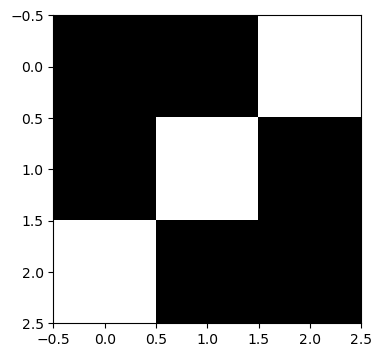

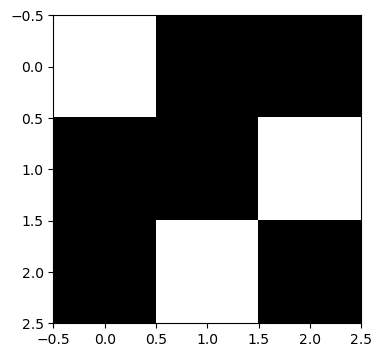

In [29]:
error_rate = 0.0001
lattice = lattice_space(12, 12)
# lattice = np.zeros((3,3))
lattice1 = lattice.copy()
lattice2 = monte_carlo_error(lattice, 1000, error_rate)
# lattice = local_decoder(lattice, )
lattice, C1 = sweeper(lattice2)
E = optimal_decoder(lattice)
C2 = C2_constructor(E, lattice)
C1, C2
R1 = np.zeros((3,3))
lattice = lattice1* ((C1 + C2) % 2 )
plt.figure(figsize=(4, 4))
plt.imshow(lattice2, cmap='binary', interpolation='nearest')

# plt.grid()
plt.show()
plt.figure(figsize=(4, 4))
plt.imshow(lattice1, cmap='binary', interpolation='nearest')
# plt.grid()
plt.show()

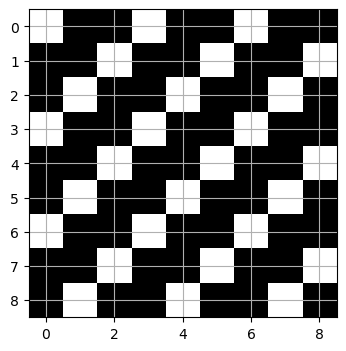

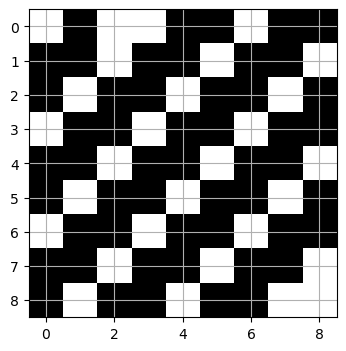

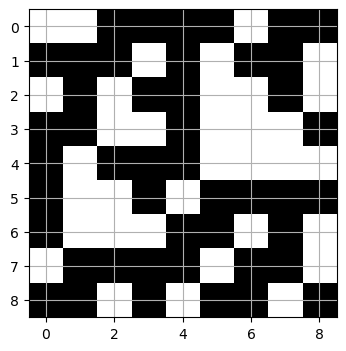

The matrix is singular and cannot be inverted.


In [171]:
import matplotlib.pyplot as plt
lattice = lattice_space(9, 9)
plt.figure(figsize=(4, 4))
plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.grid()
plt.show()
lattice = monte_carlo_error(lattice, 2, error_rate = 1)
plt.figure(figsize=(4, 4))
plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.xticks(np.linespace(0,8,))
plt.grid()
plt.show()
lattice = sweeper(lattice)
plt.figure(figsize=(4, 4))
plt.imshow(lattice, cmap='binary', interpolation='nearest')
plt.grid()
plt.show()
A = optimal_decoder(lattice)
try:
    A_inv = np.linalg.inv(A)
    
    # Step 4: Validate by checking that A * A_inv is approximately the identity matrix.
    identity = np.dot(A, A_inv)
    
    if np.allclose(identity, np.eye(A.shape[0])):
        print("\nThe inversion is verified: A * A_inv is approximately the identity matrix.")
    else:
        print("\nWarning: A * A_inv is not the identity matrix.")
    
except np.linalg.LinAlgError:
    print("The matrix is singular and cannot be inverted.")



In [ ]:
import math
checking_interval = 10
t = 0
truncate = False
L = 9
H = 9
error_rate = 0.01
beta = math.log((3+error_rate)/error_rate)/3
Lattice = lattice_space(L, H)
lattice = Lattice
while not truncate: 
    lattice = local_decoder(lattice, beta, 1, error_rate)
    if t % checking_interval == 0:
        lattice, C1 = sweeper(lattice)
        E = optimal_decoder(lattice)
        C2 = C2_constructor(E, lattice)
        weights = Lattice * C1 * C2
        sum 
        if 
            truncate = True
    else:  
        break
    t += 1

print(t)

IndexError: tuple index out of range

In [59]:
import numpy as np
from scipy.sparse import csc_matrix
import pymatching
# minimum weight perfect matching
H = csc_matrix([[1, 1, 0, 0, 0],
                [0, 1, 1, 0, 0],
                [0, 0, 1, 1, 0],
                [0, 0, 0, 1, 1]])
observables = csc_matrix([[1, 0, 0, 0, 0]])
error_probability = 0.1
weights = np.ones(H.shape[1]) * np.log((1-error_probability)/error_probability)
matching = pymatching.Matching.from_check_matrix(H, weights=weights, faults_matrix=observables)
num_shots = 1000
num_errors = 0
for i in range(num_shots):
    noise = (np.random.random(H.shape[1]) < error_probability).astype(np.uint8)
    syndrome = H@noise % 2
    predicted_observables = matching.decode(syndrome)
    actual_observables = observables@noise % 2
    num_errors += not np.array_equal(predicted_observables, actual_observables)

print(num_errors)  # prints 6
predicted_observables

13


array([0], dtype=uint8)

In [60]:
syndrome = H@noise % 2
predicted_observables = matching.decode(syndrome)
print(predicted_observables)  # prints [1 0 0 0 0]
print(noise)  # prints [1 0 0 0 0]

[0]
[0 0 0 0 0]


In [61]:
def xyz_color_z_stabilzers(H,L):
    stablizers = np.empty((0, H*L), dtype=int)
    row = -1
    for i in range(H):
        row += 1
        for j in range(L):
            line = np.zeros((L*H),dtype=int)
            line[(i+j+row*(L-1))%(H*L)] = 1
            line[(i+j+L+row*(L-1))%(H*L)] =1
            line[(i+j+L+1+row*(L-1))%(H*L)] = 1
            stablizers = np.vstack((stablizers, line))       
    return stablizers

def color_code_z_logical(L, H):
    lattice = np.zeros((L, H))
    for i in range(L):
        for j in range(H):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice.flatten()



In [62]:
H=xyz_color_z_stabilzers(3,3)
logicals = color_code_z_logical(3,3)
p = 0.01
from pymatching import Matching
matching = Matching.from_check_matrix(H, weights=np.log((1-p)/p), faults_matrix=logicals)
noise = np.random.binomial(1, 0.05, H.shape[1])
#matching = Matching(H)

ValueError: `check_matrix` must contain at most two ones per column, but column 0 has 3 ones.

In [63]:
import numpy as np

from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag


def repetition_code(n):
    """
    Parity check matrix of a repetition code with length n.
    """
    row_ind, col_ind = zip(*((i, j) for i in range(n) for j in (i, (i+1)%n)))
    data = np.ones(2*n, dtype=np.uint8)
    return csc_matrix((data, (row_ind, col_ind)))


def toric_code_x_stabilisers(L):
    """
    Sparse check matrix for the X stabilisers of a toric code with
    lattice size L, constructed as the hypergraph product of
    two repetition codes.
    """
    Hr = repetition_code(L)
    H = hstack(
            [kron(Hr, eye(Hr.shape[1])), kron(eye(Hr.shape[0]), Hr.T)],
            dtype=np.uint8
        )
    H.data = H.data % 2
    H.eliminate_zeros()
    return csc_matrix(H)
H1 = toric_code_x_stabilisers(3)
matching = pymatching.Matching(H1)
H1.toarray()

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]],
      dtype=uint8)

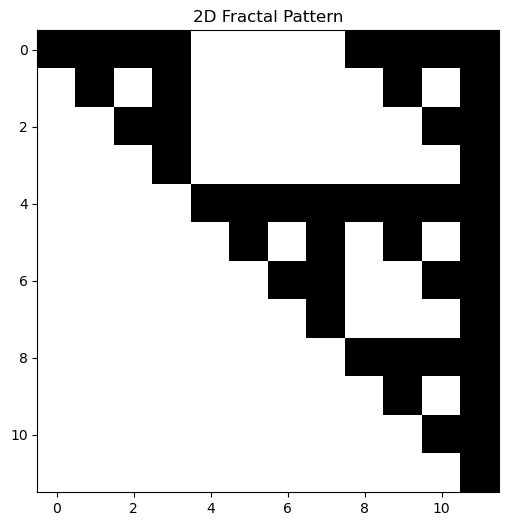

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def generate_pattern(H, L, seed_col=0, wrap=True):
    """
    Generate a 2D pattern using the rule:
        R_i^(j) = (R_i^(j+1) + R_{i+1}^{(j+1)}) mod 2
    where row j is computed from row (j+1).

    Parameters
    ----------
    H : int
        Number of rows in the grid.
    L : int
        Number of columns in the grid.
    seed_col : int
        Which column in the top row is set to 1 as the seed.
    wrap : bool
        If True, use periodic (wrap-around) boundary conditions.

    Returns
    -------
    grid : 2D numpy array of shape (H, L)
        The resulting pattern.
    """
    # Create an empty grid
    grid = np.zeros((H, L), dtype=int)

    # Place a seed (1) in the top row at column 'seed_col'
    if 0 <= seed_col < L:
        grid[H-1, seed_col] = 1
    else:
        raise ValueError("seed_col is out of range")

    # Fill rows from the top (H-1) down to the bottom (0)
    for j in range(H - 2, -1, -1):
        for i in range(L):
            if wrap:
                # Use periodic boundary: neighbor to the right wraps around using modulo L.
                right_index = (i + 1) % L
            else:
                # Without wrap, if i+1 is out of bounds, treat it as 0.
                right_index = i + 1 if i + 1 < L else None

            # If right_index is None, we assume a 0 contribution.
            right_val = grid[j+1, right_index] if right_index is not None else 0
            grid[j, i] = (grid[j+1, i] + right_val) % 2

    return grid

# --------------------- EXAMPLE USAGE --------------------- #

H, L = 12, 12
# Generate and display the pattern using periodic boundary conditions.
pattern = generate_pattern(H, L, seed_col=L-1, wrap=True)

plt.figure(figsize=(6, 6))
plt.imshow(pattern, cmap='binary', interpolation='nearest')
plt.title("2D Fractal Pattern")
#plt.axis('off')
plt.show()


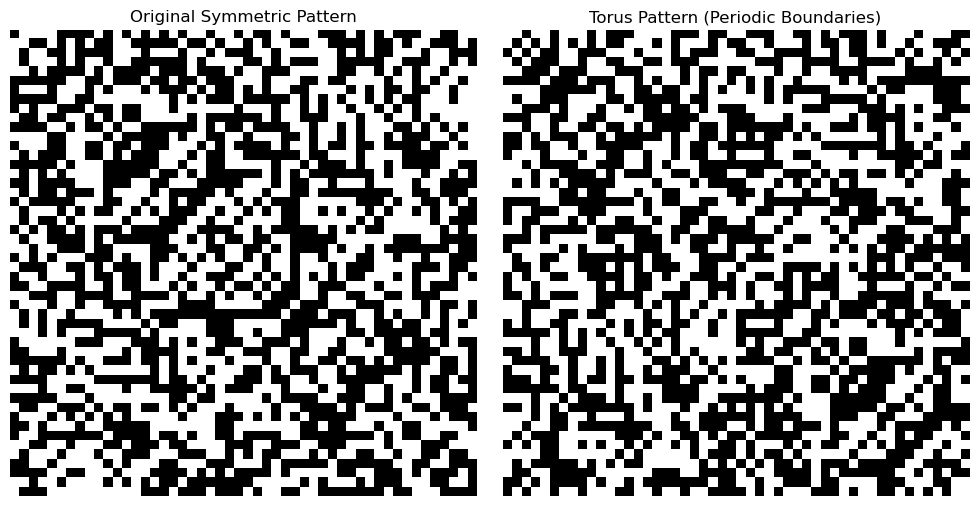

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_symmetric_pattern(N):
    """
    Generate an N x N binary pattern and force mirror symmetry along the diagonal.
    """
    # Create a random binary pattern.
    A = np.random.randint(0, 2, size=(N, N))
    # Force symmetry along the diagonal:
    # Use the upper triangle and mirror it to the lower triangle.
    A_sym = np.triu(A)
    # The diagonal is already in place; add the transpose of the strictly upper part.
    A_sym = A_sym + A_sym.T - np.diag(np.diag(A_sym))
    return A_sym

def create_torus_pattern(pattern, offset):
    """
    Given a square pattern, tile it in a 3x3 grid and extract an N x N window 
    with a given offset to simulate periodic boundary conditions.
    """
    N = pattern.shape[0]
    # Tile the pattern to simulate infinite periodic copies (a torus).
    tiled = np.tile(pattern, (3, 3))
    # Extract the window from the tiled array.
    # The offset lets you choose a different "cut" through the torus.
    torus_pattern = tiled[offset:offset+N, offset:offset+N]
    return torus_pattern

# Set grid size.
N = 50

# Generate a symmetric pattern.
pattern = generate_symmetric_pattern(N)

# To simulate the torus, we take an offset.
# For instance, offset by half the grid size gives a nontrivial cut.
offset = N // 2
torus_pattern = create_torus_pattern(pattern, offset)

# Display the original and torus pattern side by side.
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original pattern (with mirror symmetry, but not wrapped)
ax[0].imshow(pattern, cmap='gray', interpolation='none')
ax[0].set_title("Original Symmetric Pattern")
ax[0].axis('off')

# Pattern as seen on the torus (with periodic identification)
ax[1].imshow(torus_pattern, cmap='gray', interpolation='none')
ax[1].set_title("Torus Pattern (Periodic Boundaries)")
ax[1].axis('off')

plt.tight_layout()
plt.show()
